# Advanced Multi-Task: MMoE & PLE on Tenrec

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_dataset_study/blob/main/notebooks/03_tenrec_cvr/03_advanced_cvr.ipynb)
[![MMoE Paper](https://img.shields.io/badge/Paper-MMoE%20KDD%202018-blue)](https://dl.acm.org/doi/10.1145/3219819.3220007)
[![PLE Paper](https://img.shields.io/badge/Paper-PLE%20RecSys%202020-green)](https://dl.acm.org/doi/10.1145/3383313.3412236)

---

## Learning Objectives

By the end of this notebook, you will:
1. Understand Multi-gate Mixture-of-Experts (MMoE) architecture and gating mechanisms
2. Understand Progressive Layered Extraction (PLE) with shared and task-specific experts
3. Implement MMoE and PLE from scratch in PyTorch
4. Train both models on Tenrec with the ESMM multiplication trick
5. Analyze expert utilization and gating distributions
6. Perform ablation studies on number of experts and PLE extraction layers

## Prerequisites

- Completed Notebooks 01-02 (data exploration and ESMM)
- Understanding of ESMM's CTCVR = CTR x CVR decomposition
- Familiarity with mixture-of-experts concepts

---

In [1]:
import os
import json
import time
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, log_loss

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

PyTorch version: 2.4.1+cpu
Device: cpu


## 1. Theory: Multi-Task Expert Networks

### 1.1 MMoE (Ma et al., Google, KDD 2018)

Multi-gate Mixture-of-Experts (MMoE) addresses a key limitation of shared-bottom models: when tasks are loosely related, a shared representation can hurt performance.

**Architecture:**
- $n$ expert networks $\{f_1, f_2, ..., f_n\}$, each an MLP
- Each task $k$ has a gating network $g_k$ that produces a softmax distribution over experts
- Task $k$'s input to its tower is a weighted mixture of expert outputs:

$$y_k = h_k\left(\sum_{i=1}^{n} g_k^{(i)}(x) \cdot f_i(x)\right)$$

where $g_k(x) = \text{softmax}(W_k^g \cdot x)$ and $h_k$ is the task-specific tower.

> **Concept:** Unlike ESMM which uses identical shared embeddings for both towers, MMoE allows each task to dynamically select which expert knowledge to use. This provides flexibility when tasks have different optimal feature representations.

### 1.2 PLE (Tang et al., Tencent, RecSys 2020)

Progressive Layered Extraction (PLE) extends MMoE by adding **task-specific experts** alongside shared experts, and stacking multiple extraction layers.

**Architecture:**
- **Shared experts**: accessible by all tasks (like MMoE)
- **Task-specific experts**: private to each task
- **Extraction network**: gating over both shared and task-specific experts
- **Progressive stacking**: multiple extraction layers for hierarchical feature extraction

For extraction layer $l$, task $k$:

$$y_k^{(l)} = \sum_{i} g_k^{(l,i)}(x^{(l-1)}) \cdot e_i^{(l)}(x^{(l-1)})$$

where $e_i$ includes both shared experts and task-$k$-specific experts.

> **Common Pitfall:** In both MMoE and PLE for like prediction, we still use the ESMM multiplication trick (CTCVR = CTR x CVR). The expert networks replace the simple MLP towers, but the loss structure remains the same: $\mathcal{L} = \mathcal{L}_{CTR} + \mathcal{L}_{CTCVR}$.

## 2. Load Preprocessed Data

In [2]:
# Load preprocessed data
PROCESSED_DIR = Path('../../data/Tenrec/processed')

if not (PROCESSED_DIR / 'train.csv').exists():
    raise FileNotFoundError(
        f"Processed data not found in {PROCESSED_DIR.resolve()}. "
        "Please run Notebook 01 first."
    )

train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test.csv')
with open(PROCESSED_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)

feature_fields = OrderedDict(metadata['feature_fields'])
MODEL_FEATURES = metadata['model_features']

print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")
print(f"Click rate: {train_df['click'].mean():.4f}")
print(f"Like rate (all): {train_df['like'].mean():.6f}")
print(f"Like rate (clicked): {train_df.loc[train_df['click']==1, 'like'].mean():.4f}")

Train: 4,000,000 | Test: 1,000,000
Click rate: 0.2685
Like rate (all): 0.014757
Like rate (clicked): 0.0266


In [3]:
# Dataset and DataLoader
class TenrecDataset(Dataset):
    def __init__(self, df, feature_names, click_col='click', like_col='like'):
        self.features = torch.LongTensor(df[feature_names].values)
        self.click = torch.FloatTensor(df[click_col].values)
        self.like = torch.FloatTensor(df[like_col].values)
    def __len__(self): return len(self.click)
    def __getitem__(self, idx): return self.features[idx], self.click[idx], self.like[idx]

BATCH_SIZE = 4096
train_dataset = TenrecDataset(train_df, MODEL_FEATURES)
test_dataset = TenrecDataset(test_df, MODEL_FEATURES)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0, pin_memory=True)
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 977, Test batches: 123


## 3. Shared Components

Reuse the SharedEmbedding and Tower from Notebook 02.

In [4]:
class SharedEmbedding(nn.Module):
    """Shared embedding layer for all feature fields."""
    def __init__(self, feature_fields, embed_dim=16):
        super().__init__()
        self.feature_names = list(feature_fields.keys())
        self.embed_dim = embed_dim
        self.embeddings = nn.ModuleDict()
        for name, info in feature_fields.items():
            self.embeddings[name] = nn.Embedding(info['cardinality'], embed_dim, padding_idx=0)
        self.output_dim = len(feature_fields) * embed_dim
        self._init_weights()
    
    def _init_weights(self):
        for emb in self.embeddings.values():
            nn.init.xavier_uniform_(emb.weight)
            if emb.padding_idx is not None:
                emb.weight.data[emb.padding_idx].fill_(0)
    
    def forward(self, x):
        embeds = [self.embeddings[name](x[:, i]) for i, name in enumerate(self.feature_names)]
        return torch.cat(embeds, dim=1)


class Tower(nn.Module):
    """MLP tower with BatchNorm and Dropout."""
    def __init__(self, input_dim, hidden_dims=(128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hd in hidden_dims:
            layers.extend([nn.Linear(prev_dim, hd), nn.BatchNorm1d(hd), nn.ReLU(), nn.Dropout(dropout)])
            prev_dim = hd
        layers.append(nn.Linear(prev_dim, 1))
        self.mlp = nn.Sequential(*layers)
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.mlp(x)

## 4. MMoE Implementation

### 4.1 Expert and Gating Networks

In [5]:
class ExpertNetwork(nn.Module):
    """Single expert network (MLP)."""
    def __init__(self, input_dim, expert_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, expert_dim),
            nn.BatchNorm1d(expert_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(expert_dim, expert_dim),
            nn.ReLU(),
        )
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.net(x)


class GatingNetwork(nn.Module):
    """Softmax gating network for selecting experts."""
    def __init__(self, input_dim, n_experts, temperature=1.0):
        super().__init__()
        self.gate = nn.Linear(input_dim, n_experts)
        self.temperature = temperature
        nn.init.xavier_uniform_(self.gate.weight)
        nn.init.zeros_(self.gate.bias)
    
    def forward(self, x):
        return F.softmax(self.gate(x) / self.temperature, dim=1)

### 4.2 MMoE Model

In [6]:
class MMoE(nn.Module):
    """Multi-gate Mixture-of-Experts for like prediction on Tenrec.
    
    Uses ESMM-style CTCVR = CTR x CVR for addressing sample selection bias.
    
    Architecture:
        Shared Embeddings -> [Expert1, Expert2, ..., ExpertN]
                          -> CTR Gate -> weighted sum -> CTR Tower -> P(click)
                          -> CVR Gate -> weighted sum -> CVR Tower -> P(like|click)
                          -> CTCVR = CTR * CVR
    """
    
    def __init__(self, feature_fields, embed_dim=16, n_experts=8,
                 expert_dim=64, tower_hidden_dims=(128, 64),
                 dropout=0.3, ctcvr_loss_weight=1.0):
        super().__init__()
        
        self.embedding = SharedEmbedding(feature_fields, embed_dim)
        input_dim = self.embedding.output_dim
        
        self.n_experts = n_experts
        self.experts = nn.ModuleList([
            ExpertNetwork(input_dim, expert_dim, dropout=0.1)
            for _ in range(n_experts)
        ])
        
        self.ctr_gate = GatingNetwork(input_dim, n_experts)
        self.cvr_gate = GatingNetwork(input_dim, n_experts)
        
        self.ctr_tower = Tower(expert_dim, tower_hidden_dims, dropout)
        self.cvr_tower = Tower(expert_dim, tower_hidden_dims, dropout)
        
        self.ctcvr_loss_weight = ctcvr_loss_weight
        self._last_ctr_gates = None
        self._last_cvr_gates = None
    
    def forward(self, x):
        embed = self.embedding(x)
        
        expert_outputs = [expert(embed) for expert in self.experts]
        expert_outputs = torch.stack(expert_outputs, dim=1)
        
        ctr_gate_weights = self.ctr_gate(embed)
        self._last_ctr_gates = ctr_gate_weights.detach()
        ctr_expert_out = torch.sum(
            expert_outputs * ctr_gate_weights.unsqueeze(2), dim=1)
        
        cvr_gate_weights = self.cvr_gate(embed)
        self._last_cvr_gates = cvr_gate_weights.detach()
        cvr_expert_out = torch.sum(
            expert_outputs * cvr_gate_weights.unsqueeze(2), dim=1)
        
        ctr_pred = torch.sigmoid(self.ctr_tower(ctr_expert_out).squeeze(1))
        cvr_pred = torch.sigmoid(self.cvr_tower(cvr_expert_out).squeeze(1))
        
        ctcvr_pred = ctr_pred * cvr_pred
        
        return ctr_pred, cvr_pred, ctcvr_pred
    
    def compute_loss(self, ctr_pred, ctcvr_pred, click_label, like_label):
        ctr_loss = F.binary_cross_entropy(ctr_pred, click_label)
        ctcvr_pred_clipped = torch.clamp(ctcvr_pred, 1e-7, 1 - 1e-7)
        ctcvr_loss = F.binary_cross_entropy(ctcvr_pred_clipped, like_label)
        return ctr_loss + self.ctcvr_loss_weight * ctcvr_loss, ctr_loss, ctcvr_loss


model_mmoe = MMoE(
    feature_fields=feature_fields,
    embed_dim=16,
    n_experts=8,
    expert_dim=64,
    tower_hidden_dims=[128, 64],
    dropout=0.3
).to(device)

print(f"MMoE Model:")
print(f"  Experts: {model_mmoe.n_experts}")
print(f"  Total parameters: {sum(p.numel() for p in model_mmoe.parameters()):,}")
print(f"\nComponent parameter counts:")
for name, module in model_mmoe.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f"  {name}: {n_params:,} params")

MMoE Model:
  Experts: 8
  Total parameters: 10,815,906

Component parameter counts:
  embedding: 10,704,784 params
  experts: 75,776 params
  ctr_gate: 648 params
  cvr_gate: 648 params
  ctr_tower: 17,025 params
  cvr_tower: 17,025 params


## 5. PLE Implementation

### 5.1 Extraction Network

In [7]:
class PLEExtractionLayer(nn.Module):
    """Single PLE extraction layer.
    
    Contains:
    - Shared experts (used by all tasks)
    - Task-specific experts (one set per task)
    - Task-specific gating networks
    """
    
    def __init__(self, input_dim, expert_dim, n_shared_experts=4,
                 n_task_experts=2, n_tasks=2, dropout=0.1):
        super().__init__()
        self.n_shared_experts = n_shared_experts
        self.n_task_experts = n_task_experts
        self.n_tasks = n_tasks
        self.expert_dim = expert_dim
        
        total_experts_per_task = n_shared_experts + n_task_experts
        
        self.shared_experts = nn.ModuleList([
            ExpertNetwork(input_dim, expert_dim, dropout)
            for _ in range(n_shared_experts)
        ])
        
        self.task_experts = nn.ModuleList([
            nn.ModuleList([
                ExpertNetwork(input_dim, expert_dim, dropout)
                for _ in range(n_task_experts)
            ])
            for _ in range(n_tasks)
        ])
        
        self.gates = nn.ModuleList([
            GatingNetwork(input_dim, total_experts_per_task)
            for _ in range(n_tasks)
        ])
        
        self._last_gate_weights = [None] * n_tasks
    
    def forward(self, x):
        if isinstance(x, torch.Tensor):
            task_inputs = [x] * self.n_tasks
        else:
            task_inputs = x
        
        shared_outs = [expert(task_inputs[0]) for expert in self.shared_experts]
        
        task_outputs = []
        for task_idx in range(self.n_tasks):
            task_specific_outs = [
                expert(task_inputs[task_idx])
                for expert in self.task_experts[task_idx]
            ]
            
            all_expert_outs = shared_outs + task_specific_outs
            stacked = torch.stack(all_expert_outs, dim=1)
            
            gate_weights = self.gates[task_idx](task_inputs[task_idx])
            self._last_gate_weights[task_idx] = gate_weights.detach()
            
            task_out = torch.sum(stacked * gate_weights.unsqueeze(2), dim=1)
            task_outputs.append(task_out)
        
        return task_outputs


class PLE(nn.Module):
    """Progressive Layered Extraction for like prediction on Tenrec.
    
    Uses multiple extraction layers with shared + task-specific experts.
    Still uses ESMM-style CTCVR = CTR x CVR.
    """
    
    def __init__(self, feature_fields, embed_dim=16,
                 n_extraction_layers=2, n_shared_experts=4,
                 n_task_experts=2, expert_dim=64,
                 tower_hidden_dims=(128, 64), dropout=0.3,
                 ctcvr_loss_weight=1.0):
        super().__init__()
        
        self.embedding = SharedEmbedding(feature_fields, embed_dim)
        input_dim = self.embedding.output_dim
        self.n_extraction_layers = n_extraction_layers
        
        self.extraction_layers = nn.ModuleList()
        for layer_idx in range(n_extraction_layers):
            layer_input_dim = input_dim if layer_idx == 0 else expert_dim
            self.extraction_layers.append(
                PLEExtractionLayer(
                    input_dim=layer_input_dim,
                    expert_dim=expert_dim,
                    n_shared_experts=n_shared_experts,
                    n_task_experts=n_task_experts,
                    n_tasks=2,
                    dropout=0.1
                )
            )
        
        self.ctr_tower = Tower(expert_dim, tower_hidden_dims, dropout)
        self.cvr_tower = Tower(expert_dim, tower_hidden_dims, dropout)
        
        self.ctcvr_loss_weight = ctcvr_loss_weight
    
    def forward(self, x):
        embed = self.embedding(x)
        
        task_inputs = embed
        for layer in self.extraction_layers:
            task_outputs = layer(task_inputs)
            task_inputs = task_outputs
        
        ctr_features, cvr_features = task_outputs
        
        ctr_pred = torch.sigmoid(self.ctr_tower(ctr_features).squeeze(1))
        cvr_pred = torch.sigmoid(self.cvr_tower(cvr_features).squeeze(1))
        
        ctcvr_pred = ctr_pred * cvr_pred
        
        return ctr_pred, cvr_pred, ctcvr_pred
    
    def compute_loss(self, ctr_pred, ctcvr_pred, click_label, like_label):
        ctr_loss = F.binary_cross_entropy(ctr_pred, click_label)
        ctcvr_pred_clipped = torch.clamp(ctcvr_pred, 1e-7, 1 - 1e-7)
        ctcvr_loss = F.binary_cross_entropy(ctcvr_pred_clipped, like_label)
        return ctr_loss + self.ctcvr_loss_weight * ctcvr_loss, ctr_loss, ctcvr_loss


model_ple = PLE(
    feature_fields=feature_fields,
    embed_dim=16,
    n_extraction_layers=2,
    n_shared_experts=4,
    n_task_experts=2,
    expert_dim=64,
    tower_hidden_dims=[128, 64],
    dropout=0.3
).to(device)

print(f"PLE Model:")
print(f"  Extraction layers: {model_ple.n_extraction_layers}")
print(f"  Total parameters: {sum(p.numel() for p in model_ple.parameters()):,}")
print(f"\nComponent parameter counts:")
for name, module in model_ple.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f"  {name}: {n_params:,} params")

PLE Model:
  Extraction layers: 2
  Total parameters: 10,883,946

Component parameter counts:
  embedding: 10,704,784 params
  extraction_layers: 145,112 params
  ctr_tower: 17,025 params
  cvr_tower: 17,025 params


## 6. Training

> **Pro Tip:** MMoE and PLE use the same training procedure as ESMM. The only difference is the model architecture -- the loss function (CTR + CTCVR) remains identical. This makes these models drop-in replacements for the ESMM towers.

In [8]:
def evaluate_model(model, data_loader, device=device):
    """Evaluate multi-task model."""
    model.eval()
    all_ctr, all_cvr, all_ctcvr = [], [], []
    all_clicks, all_likes = [], []
    
    with torch.no_grad():
        for features, clicks, likes in data_loader:
            features = features.to(device)
            ctr_p, cvr_p, ctcvr_p = model(features)
            all_ctr.append(ctr_p.cpu().numpy())
            all_cvr.append(cvr_p.cpu().numpy())
            all_ctcvr.append(ctcvr_p.cpu().numpy())
            all_clicks.append(clicks.numpy())
            all_likes.append(likes.numpy())
    
    clicks = np.concatenate(all_clicks)
    likes = np.concatenate(all_likes)
    ctr_preds = np.concatenate(all_ctr)
    cvr_preds = np.concatenate(all_cvr)
    ctcvr_preds = np.concatenate(all_ctcvr)
    
    results = {
        'ctr_auc': roc_auc_score(clicks, ctr_preds),
        'ctcvr_auc': roc_auc_score(likes, ctcvr_preds),
        'like_auc_all': roc_auc_score(likes, ctcvr_preds),
        'ctr_logloss': log_loss(clicks, np.clip(ctr_preds, 1e-7, 1-1e-7)),
        'ctcvr_logloss': log_loss(likes, np.clip(ctcvr_preds, 1e-7, 1-1e-7)),
    }
    
    clicked_mask = clicks == 1
    if clicked_mask.sum() > 0 and likes[clicked_mask].sum() > 0:
        results['like_auc_clicked'] = roc_auc_score(likes[clicked_mask], cvr_preds[clicked_mask])
    else:
        results['like_auc_clicked'] = 0.5
    
    return results


def train_model(model, train_loader, test_loader, model_name='Model',
                n_epochs=15, lr=1e-3, weight_decay=1e-5, patience=3, device=device):
    """Generic training loop for MMoE/PLE models."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=1, verbose=True)
    
    history = {'train_loss': [], 'ctr_loss': [], 'ctcvr_loss': [],
               'test_ctr_auc': [], 'test_like_auc_all': [], 'test_ctcvr_auc': [],
               'test_like_auc_clicked': [], 'epoch_time': []}
    
    best_ctcvr_auc = 0
    best_state = None
    patience_counter = 0
    
    print(f"\nTraining {model_name}...")
    print("=" * 90)
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = epoch_ctr = epoch_ctcvr = 0
        n_batches = 0
        start_time = time.time()
        
        for features, clicks, likes in train_loader:
            features = features.to(device)
            clicks = clicks.to(device)
            likes = likes.to(device)
            
            ctr_pred, cvr_pred, ctcvr_pred = model(features)
            total_loss, ctr_loss, ctcvr_loss = model.compute_loss(
                ctr_pred, ctcvr_pred, clicks, likes)
            
            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            
            epoch_loss += total_loss.item()
            epoch_ctr += ctr_loss.item()
            epoch_ctcvr += ctcvr_loss.item()
            n_batches += 1
        
        epoch_time = time.time() - start_time
        test_results = evaluate_model(model, test_loader, device)
        
        history['train_loss'].append(epoch_loss / n_batches)
        history['ctr_loss'].append(epoch_ctr / n_batches)
        history['ctcvr_loss'].append(epoch_ctcvr / n_batches)
        history['test_ctr_auc'].append(test_results['ctr_auc'])
        history['test_like_auc_all'].append(test_results['like_auc_all'])
        history['test_ctcvr_auc'].append(test_results['ctcvr_auc'])
        history['test_like_auc_clicked'].append(test_results['like_auc_clicked'])
        history['epoch_time'].append(epoch_time)
        
        scheduler.step(test_results['ctcvr_auc'])
        
        if test_results['ctcvr_auc'] > best_ctcvr_auc:
            best_ctcvr_auc = test_results['ctcvr_auc']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            marker = ' *'
        else:
            patience_counter += 1
            marker = ''
        
        print(f"Epoch {epoch+1:2d}/{n_epochs} ({epoch_time:.1f}s) | "
              f"Loss: {epoch_loss/n_batches:.4f} | "
              f"CTR AUC: {test_results['ctr_auc']:.4f} | "
              f"Like AUC: {test_results['like_auc_all']:.4f} | "
              f"CTCVR AUC: {test_results['ctcvr_auc']:.4f}{marker}")
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
    
    print(f"\n{model_name} best CTCVR AUC: {best_ctcvr_auc:.4f}")
    return history

In [9]:
# Train MMoE
mmoe_history = train_model(
    model_mmoe, train_loader, test_loader, model_name='MMoE',
    n_epochs=15, lr=1e-3, weight_decay=1e-5, patience=3
)


Training MMoE...


Epoch  1/15 (203.9s) | Loss: 0.5818 | CTR AUC: 0.6930 | Like AUC: 0.6870 | CTCVR AUC: 0.6870 *


Epoch  2/15 (224.6s) | Loss: 0.5124 | CTR AUC: 0.6957 | Like AUC: 0.6879 | CTCVR AUC: 0.6879 *


Epoch  3/15 (200.8s) | Loss: 0.4749 | CTR AUC: 0.6821 | Like AUC: 0.6517 | CTCVR AUC: 0.6517


Epoch  4/15 (139.0s) | Loss: 0.4452 | CTR AUC: 0.6795 | Like AUC: 0.6350 | CTCVR AUC: 0.6350


Epoch  5/15 (175.6s) | Loss: 0.4005 | CTR AUC: 0.6679 | Like AUC: 0.6184 | CTCVR AUC: 0.6184
Early stopping at epoch 5

MMoE best CTCVR AUC: 0.6879


In [10]:
# Train PLE
ple_history = train_model(
    model_ple, train_loader, test_loader, model_name='PLE',
    n_epochs=15, lr=1e-3, weight_decay=1e-5, patience=3
)


Training PLE...


Epoch  1/15 (210.3s) | Loss: 0.5820 | CTR AUC: 0.6924 | Like AUC: 0.6817 | CTCVR AUC: 0.6817 *


Epoch  2/15 (168.5s) | Loss: 0.5113 | CTR AUC: 0.6936 | Like AUC: 0.6753 | CTCVR AUC: 0.6753


Epoch  3/15 (167.0s) | Loss: 0.4692 | CTR AUC: 0.6866 | Like AUC: 0.6454 | CTCVR AUC: 0.6454


Epoch  4/15 (166.2s) | Loss: 0.4261 | CTR AUC: 0.6719 | Like AUC: 0.6146 | CTCVR AUC: 0.6146
Early stopping at epoch 4

PLE best CTCVR AUC: 0.6817


## 7. Comparison with ESMM

In [11]:
# Load ESMM results if available
esmm_results_loaded = None
if (PROCESSED_DIR / 'esmm_results.json').exists():
    with open(PROCESSED_DIR / 'esmm_results.json', 'r') as f:
        esmm_saved = json.load(f)
    esmm_results_loaded = esmm_saved.get('esmm', {})

mmoe_results = evaluate_model(model_mmoe, test_loader)
ple_results = evaluate_model(model_ple, test_loader)

print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(f"{'Metric':<30} ", end='')
if esmm_results_loaded:
    print(f"{'ESMM':>12} ", end='')
print(f"{'MMoE':>12} {'PLE':>12}")
print("-" * 80)

for metric in ['ctr_auc', 'like_auc_all', 'like_auc_clicked', 'ctcvr_auc']:
    label = metric.replace('_', ' ').upper()
    print(f"{label:<30} ", end='')
    if esmm_results_loaded and metric in esmm_results_loaded:
        print(f"{esmm_results_loaded[metric]:>12.4f} ", end='')
    elif esmm_results_loaded:
        print(f"{'N/A':>12} ", end='')
    print(f"{mmoe_results.get(metric, 0):>12.4f} {ple_results.get(metric, 0):>12.4f}")

print("=" * 80)

print(f"\n{'Parameter Count':<30} ", end='')
if esmm_results_loaded:
    print(f"{'(see NB02)':>12} ", end='')
print(f"{sum(p.numel() for p in model_mmoe.parameters()):>12,} "
      f"{sum(p.numel() for p in model_ple.parameters()):>12,}")

MODEL COMPARISON
Metric                                 ESMM         MMoE          PLE
--------------------------------------------------------------------------------
CTR AUC                              0.6965       0.6957       0.6924
LIKE AUC ALL                         0.6940       0.6879       0.6817
LIKE AUC CLICKED                     0.7084       0.7023       0.7021
CTCVR AUC                            0.6940       0.6879       0.6817

Parameter Count                  (see NB02)   10,815,906   10,883,946


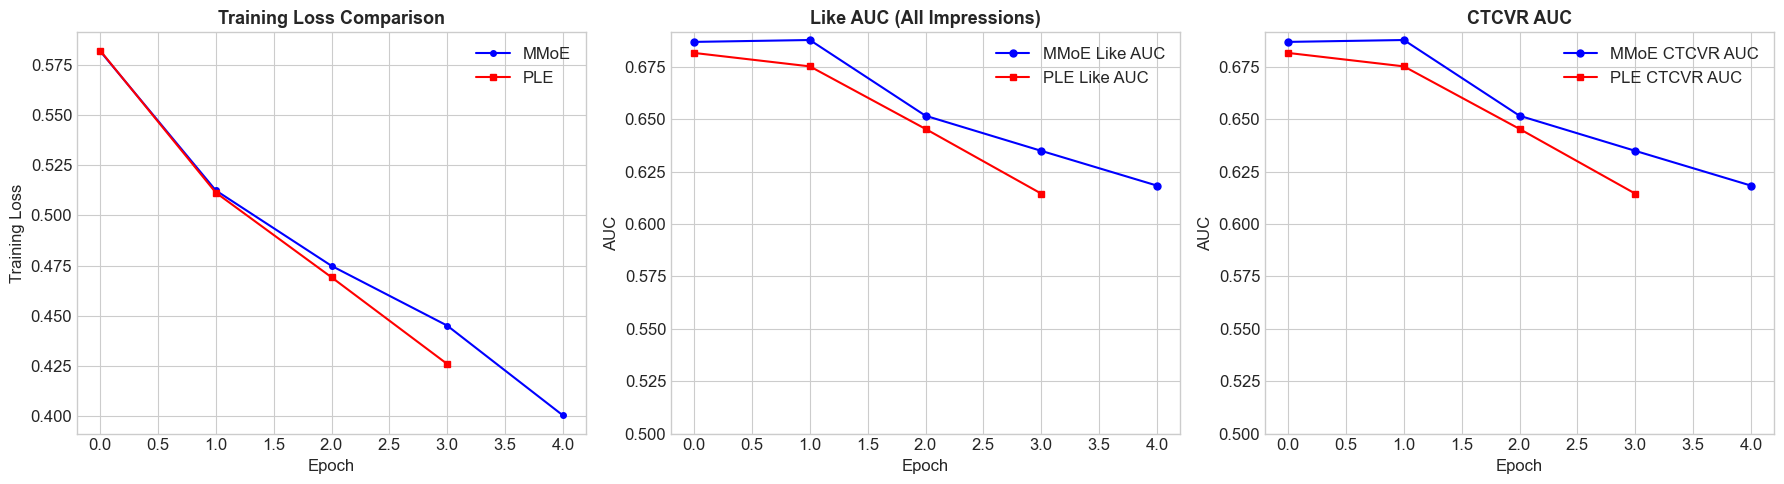

In [12]:
# Training curve comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(mmoe_history['train_loss'], 'b-o', label='MMoE', markersize=4)
ax.plot(ple_history['train_loss'], 'r-s', label='PLE', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss Comparison', fontsize=13, fontweight='bold')
ax.legend()

ax = axes[1]
ax.plot(mmoe_history['test_like_auc_all'], 'b-o', label='MMoE Like AUC', markersize=5)
ax.plot(ple_history['test_like_auc_all'], 'r-s', label='PLE Like AUC', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Like AUC (All Impressions)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, None)

ax = axes[2]
ax.plot(mmoe_history['test_ctcvr_auc'], 'b-o', label='MMoE CTCVR AUC', markersize=5)
ax.plot(ple_history['test_ctcvr_auc'], 'r-s', label='PLE CTCVR AUC', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('CTCVR AUC', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, None)

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'advanced_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Expert Utilization Analysis

> **Concept:** Understanding which experts are used by which task reveals how the model partitions knowledge. In a well-trained MMoE, different tasks should weight experts differently, indicating task-specific feature extraction.

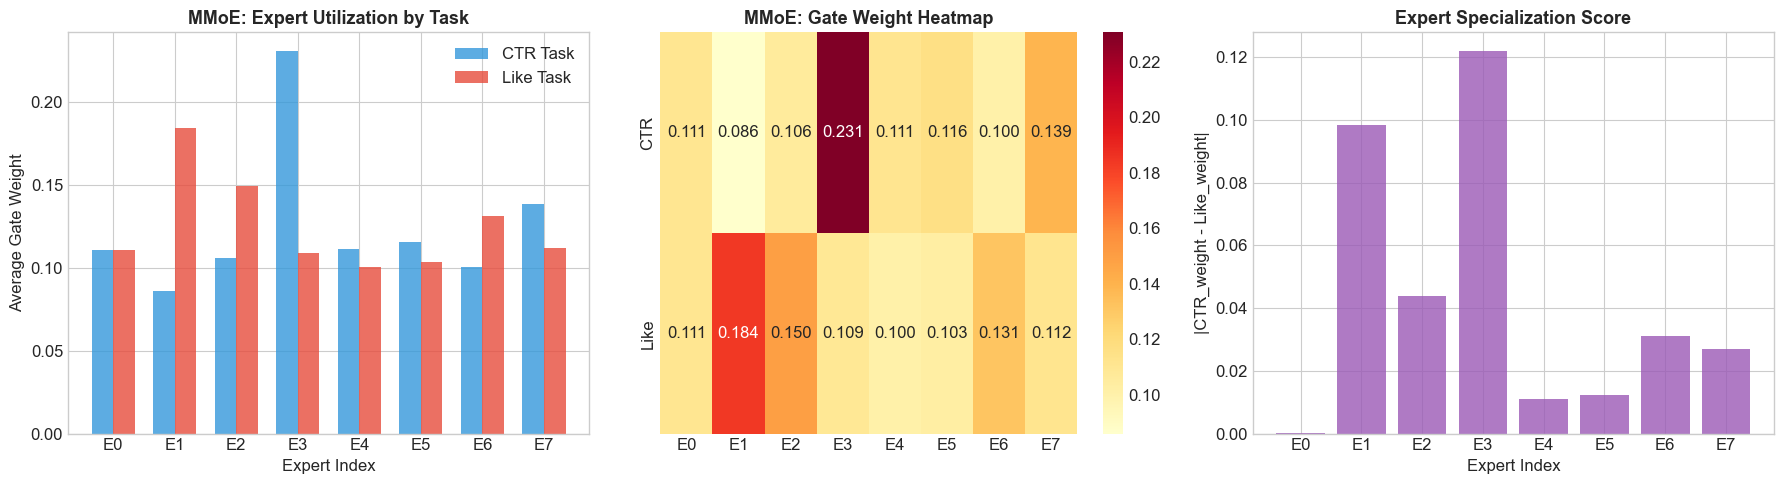


Expert Utilization Summary:
  Expert 0: CTR=0.111, Like=0.111 -> Leans Like (spec=0.000)
  Expert 1: CTR=0.086, Like=0.184 -> Leans Like (spec=0.098)
  Expert 2: CTR=0.106, Like=0.150 -> Leans Like (spec=0.044)
  Expert 3: CTR=0.231, Like=0.109 -> Leans CTR (spec=0.122)
  Expert 4: CTR=0.111, Like=0.100 -> Leans CTR (spec=0.011)
  Expert 5: CTR=0.116, Like=0.103 -> Leans CTR (spec=0.012)
  Expert 6: CTR=0.100, Like=0.131 -> Leans Like (spec=0.031)
  Expert 7: CTR=0.139, Like=0.112 -> Leans CTR (spec=0.027)


In [13]:
# Collect gating weights from MMoE
model_mmoe.eval()
all_ctr_gates = []
all_cvr_gates = []

with torch.no_grad():
    for features, _, _ in test_loader:
        features = features.to(device)
        _ = model_mmoe(features)
        all_ctr_gates.append(model_mmoe._last_ctr_gates.cpu().numpy())
        all_cvr_gates.append(model_mmoe._last_cvr_gates.cpu().numpy())

ctr_gates = np.concatenate(all_ctr_gates)
cvr_gates = np.concatenate(all_cvr_gates)

avg_ctr_gates = ctr_gates.mean(axis=0)
avg_cvr_gates = cvr_gates.mean(axis=0)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
x = np.arange(len(avg_ctr_gates))
width = 0.35
ax.bar(x - width/2, avg_ctr_gates, width, label='CTR Task', color='#3498db', alpha=0.8)
ax.bar(x + width/2, avg_cvr_gates, width, label='Like Task', color='#e74c3c', alpha=0.8)
ax.set_xlabel('Expert Index')
ax.set_ylabel('Average Gate Weight')
ax.set_title('MMoE: Expert Utilization by Task', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'E{i}' for i in range(len(avg_ctr_gates))])
ax.legend()

ax = axes[1]
gate_matrix = np.vstack([avg_ctr_gates, avg_cvr_gates])
sns.heatmap(gate_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=[f'E{i}' for i in range(gate_matrix.shape[1])],
            yticklabels=['CTR', 'Like'], ax=ax)
ax.set_title('MMoE: Gate Weight Heatmap', fontsize=13, fontweight='bold')

ax = axes[2]
specialization = np.abs(avg_ctr_gates - avg_cvr_gates)
ax.bar(range(len(specialization)), specialization, color='#9b59b6', alpha=0.8)
ax.set_xlabel('Expert Index')
ax.set_ylabel('|CTR_weight - Like_weight|')
ax.set_title('Expert Specialization Score', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(specialization)))
ax.set_xticklabels([f'E{i}' for i in range(len(specialization))])

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'expert_utilization.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nExpert Utilization Summary:")
for i in range(len(avg_ctr_gates)):
    dominant = 'CTR' if avg_ctr_gates[i] > avg_cvr_gates[i] else 'Like'
    print(f"  Expert {i}: CTR={avg_ctr_gates[i]:.3f}, Like={avg_cvr_gates[i]:.3f} "
          f"-> Leans {dominant} (spec={specialization[i]:.3f})")

## 9. Ablation Studies

In [14]:
# Ablation 1: Number of experts in MMoE
print("=" * 70)
print("ABLATION 1: Number of Experts (MMoE)")
print("=" * 70)

expert_results = {}

for n_exp in [2, 4, 8, 16]:
    print(f"\n--- n_experts = {n_exp} ---")
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    
    model_exp = MMoE(
        feature_fields, embed_dim=16, n_experts=n_exp,
        expert_dim=64, tower_hidden_dims=[128, 64], dropout=0.3
    ).to(device)
    
    n_params = sum(p.numel() for p in model_exp.parameters())
    print(f"Parameters: {n_params:,}")
    
    hist = train_model(model_exp, train_loader, test_loader,
                       model_name=f'MMoE-{n_exp}exp', n_epochs=10, patience=3)
    
    res = evaluate_model(model_exp, test_loader)
    res['n_params'] = n_params
    res['avg_epoch_time'] = np.mean(hist['epoch_time'])
    expert_results[n_exp] = res

print("\n" + "=" * 70)
print("Number of Experts Ablation Summary")
print("=" * 70)
print(f"{'Experts':>8} {'Params':>10} {'CTR AUC':>10} {'Like AUC':>10} {'CTCVR AUC':>10} {'Time/ep':>8}")
print("-" * 58)
for n_exp, r in expert_results.items():
    print(f"{n_exp:>8} {r['n_params']:>10,} {r['ctr_auc']:>10.4f} "
          f"{r['like_auc_all']:>10.4f} {r['ctcvr_auc']:>10.4f} {r['avg_epoch_time']:>7.1f}s")

ABLATION 1: Number of Experts (MMoE)

--- n_experts = 2 ---
Parameters: 10,758,102

Training MMoE-2exp...


Epoch  1/10 (163.4s) | Loss: 0.5888 | CTR AUC: 0.6930 | Like AUC: 0.6909 | CTCVR AUC: 0.6909 *


Epoch  2/10 (220.3s) | Loss: 0.5142 | CTR AUC: 0.6950 | Like AUC: 0.6913 | CTCVR AUC: 0.6913 *


Epoch  3/10 (262.1s) | Loss: 0.4799 | CTR AUC: 0.6870 | Like AUC: 0.6715 | CTCVR AUC: 0.6715


Epoch  4/10 (230.3s) | Loss: 0.4513 | CTR AUC: 0.6763 | Like AUC: 0.6397 | CTCVR AUC: 0.6397


...

Epoch  2/10 (149.0s) | Loss: 0.5114 | CTR AUC: 0.6958 | Like AUC: 0.6991 | CTCVR AUC: 0.6991 *


Epoch  3/10 (148.9s) | Loss: 0.4720 | CTR AUC: 0.6863 | Like AUC: 0.6680 | CTCVR AUC: 0.6680


Epoch  4/10 (148.8s) | Loss: 0.4434 | CTR AUC: 0.6764 | Like AUC: 0.6382 | CTCVR AUC: 0.6382


Epoch  5/10 (149.2s) | Loss: 0.3971 | CTR AUC: 0.6681 | Like AUC: 0.6190 | CTCVR AUC: 0.6190
Early stopping at epoch 5

MMoE-16exp best CTCVR AUC: 0.6991



Number of Experts Ablation Summary
 Experts     Params    CTR AUC   Like AUC  CTCVR AUC  Time/ep
----------------------------------------------------------
       2 10,758,102     0.6950     0.6913     0.6913   220.5s
       4 10,777,370     0.6951     0.6939     0.6939   236.1s
       8 10,815,906     0.6936     0.6922     0.6922   191.6s
      16 10,892,978     0.6958     0.6991     0.6991   148.8s


In [15]:
# Ablation 2: Number of PLE extraction layers
print("=" * 70)
print("ABLATION 2: Number of Extraction Layers (PLE)")
print("=" * 70)

layer_results = {}

for n_layers in [1, 2, 3]:
    print(f"\n--- n_extraction_layers = {n_layers} ---")
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    
    model_layers = PLE(
        feature_fields, embed_dim=16, n_extraction_layers=n_layers,
        n_shared_experts=4, n_task_experts=2, expert_dim=64,
        tower_hidden_dims=[128, 64], dropout=0.3
    ).to(device)
    
    n_params = sum(p.numel() for p in model_layers.parameters())
    print(f"Parameters: {n_params:,}")
    
    hist = train_model(model_layers, train_loader, test_loader,
                       model_name=f'PLE-{n_layers}L', n_epochs=10, patience=3)
    
    res = evaluate_model(model_layers, test_loader)
    res['n_params'] = n_params
    res['avg_epoch_time'] = np.mean(hist['epoch_time'])
    layer_results[n_layers] = res

print("\n" + "=" * 70)
print("Extraction Layers Ablation Summary")
print("=" * 70)
print(f"{'Layers':>8} {'Params':>10} {'CTR AUC':>10} {'Like AUC':>10} {'CTCVR AUC':>10} {'Time/ep':>8}")
print("-" * 58)
for n_l, r in layer_results.items():
    print(f"{n_l:>8} {r['n_params']:>10,} {r['ctr_auc']:>10.4f} "
          f"{r['like_auc_all']:>10.4f} {r['ctcvr_auc']:>10.4f} {r['avg_epoch_time']:>7.1f}s")

ABLATION 2: Number of Extraction Layers (PLE)

--- n_extraction_layers = 1 ---
Parameters: 10,815,582

Training PLE-1L...


Epoch  1/10 (123.9s) | Loss: 0.5775 | CTR AUC: 0.6938 | Like AUC: 0.6931 | CTCVR AUC: 0.6931 *


Epoch  2/10 (124.4s) | Loss: 0.5114 | CTR AUC: 0.6953 | Like AUC: 0.6894 | CTCVR AUC: 0.6894


Epoch  3/10 (124.6s) | Loss: 0.4719 | CTR AUC: 0.6894 | Like AUC: 0.6753 | CTCVR AUC: 0.6753


Epoch  4/10 (124.1s) | Loss: 0.4244 | CTR AUC: 0.6764 | Like AUC: 0.6572 | CTCVR AUC: 0.6572
Early stopping at epoch 4

PLE-1L best CTCVR AUC: 0.6931


...

Epoch  1/10 (168.7s) | Loss: 0.5874 | CTR AUC: 0.6913 | Like AUC: 0.6833 | CTCVR AUC: 0.6833 *


Epoch  2/10 (169.5s) | Loss: 0.5148 | CTR AUC: 0.6950 | Like AUC: 0.6785 | CTCVR AUC: 0.6785


Epoch  3/10 (169.8s) | Loss: 0.4712 | CTR AUC: 0.6878 | Like AUC: 0.6417 | CTCVR AUC: 0.6417


Epoch  4/10 (169.5s) | Loss: 0.4306 | CTR AUC: 0.6746 | Like AUC: 0.6303 | CTCVR AUC: 0.6303
Early stopping at epoch 4

PLE-3L best CTCVR AUC: 0.6833



Extraction Layers Ablation Summary
  Layers     Params    CTR AUC   Like AUC  CTCVR AUC  Time/ep
----------------------------------------------------------
       1 10,815,582     0.6938     0.6931     0.6931   124.2s
       2 10,883,946     0.6901     0.6937     0.6937   146.7s
       3 10,952,310     0.6913     0.6833     0.6833   169.4s


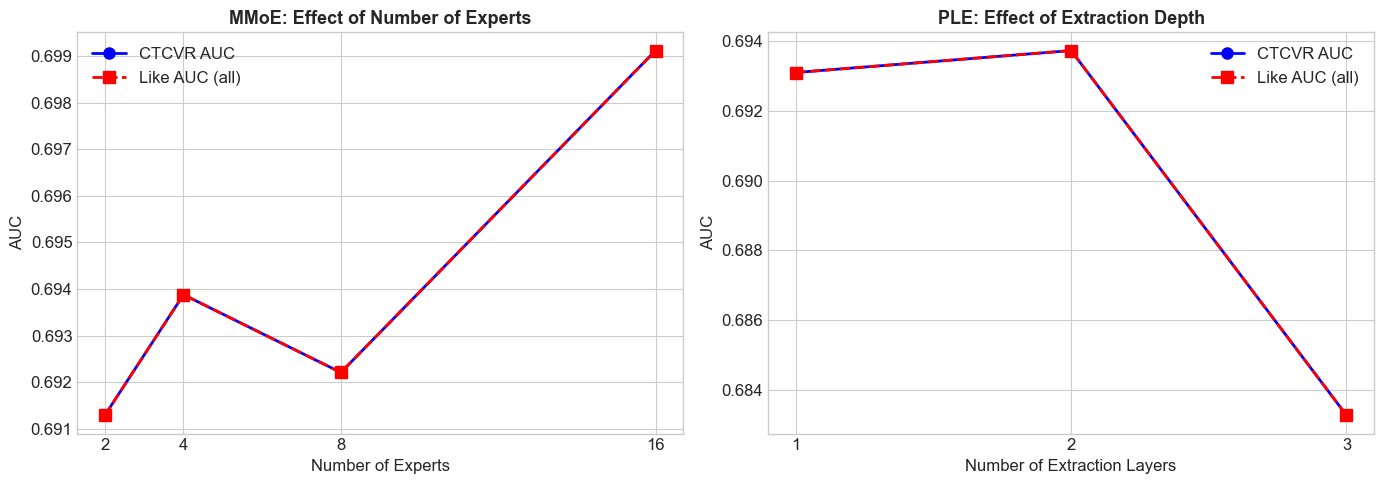

In [16]:
# Visualize ablation results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
n_exps = list(expert_results.keys())
ctcvr_aucs = [expert_results[n]['ctcvr_auc'] for n in n_exps]
like_aucs = [expert_results[n]['like_auc_all'] for n in n_exps]
ax.plot(n_exps, ctcvr_aucs, 'b-o', label='CTCVR AUC', markersize=8, linewidth=2)
ax.plot(n_exps, like_aucs, 'r--s', label='Like AUC (all)', markersize=8, linewidth=2)
ax.set_xlabel('Number of Experts')
ax.set_ylabel('AUC')
ax.set_title('MMoE: Effect of Number of Experts', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(n_exps)

ax = axes[1]
n_ls = list(layer_results.keys())
ctcvr_aucs = [layer_results[n]['ctcvr_auc'] for n in n_ls]
like_aucs = [layer_results[n]['like_auc_all'] for n in n_ls]
ax.plot(n_ls, ctcvr_aucs, 'b-o', label='CTCVR AUC', markersize=8, linewidth=2)
ax.plot(n_ls, like_aucs, 'r--s', label='Like AUC (all)', markersize=8, linewidth=2)
ax.set_xlabel('Number of Extraction Layers')
ax.set_ylabel('AUC')
ax.set_title('PLE: Effect of Extraction Depth', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(n_ls)

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'ablation_results.png'), dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Save models and results
torch.save(model_mmoe.state_dict(), str(PROCESSED_DIR / 'mmoe_model.pt'))
torch.save(model_ple.state_dict(), str(PROCESSED_DIR / 'ple_model.pt'))

def convert_for_json(obj):
    if isinstance(obj, (np.floating, np.float64, np.float32)): return float(obj)
    if isinstance(obj, (np.integer, np.int64, np.int32)): return int(obj)
    if isinstance(obj, dict): return {k: convert_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list): return [convert_for_json(v) for v in obj]
    return obj

advanced_results = {
    'mmoe': convert_for_json(mmoe_results),
    'ple': convert_for_json(ple_results),
    'mmoe_history': convert_for_json(mmoe_history),
    'ple_history': convert_for_json(ple_history),
}

with open(PROCESSED_DIR / 'advanced_results.json', 'w') as f:
    json.dump(advanced_results, f, indent=2)

print("Models and results saved.")

Models and results saved.


---

## Exercises

### Exercise 1: Expert Dropout
Implement "expert dropout" where during training, each expert is randomly dropped with probability 0.1. Does this improve generalization?

In [18]:
# TODO: Exercise 1
# Modify MMoE forward to randomly zero out expert outputs during training
# Hint: Use torch.bernoulli to create a mask over expert outputs

pass

### Exercise 2: Task-Specific Learning Rates
Try using different learning rates for shared components vs task-specific components. Use 1e-3 for shared embeddings/experts and 1e-4 for task towers.

In [19]:
# TODO: Exercise 2
# Use parameter groups in the optimizer:
# optimizer = torch.optim.Adam([
#     {'params': shared_params, 'lr': 1e-3},
#     {'params': tower_params, 'lr': 1e-4},
# ])

pass

### Exercise 3: Gating Diversity Loss
Add a regularization term that encourages different tasks to use different gating patterns. Implement $\mathcal{L}_{div} = -\|g_{ctr} - g_{cvr}\|_2^2$ and add it to the total loss.

In [20]:
# TODO: Exercise 3
# Modify compute_loss to add diversity regularization
# L_div = -lambda * ||avg_ctr_gate - avg_cvr_gate||^2
# This encourages the tasks to specialize on different experts

pass

---

## Summary & Key Takeaways

### What We Learned

1. **MMoE provides flexible task routing**: Unlike ESMM's shared-bottom approach, MMoE allows each task to dynamically select which expert knowledge to use. This is beneficial when CTR and like tasks have different optimal feature representations.

2. **PLE adds task-specific experts**: By combining shared and task-specific experts with progressive extraction, PLE can capture both common and task-unique patterns. The progressive stacking enables hierarchical feature extraction.

3. **Expert specialization emerges naturally**: Without explicit supervision, different experts learn to specialize for different tasks. The gating analysis reveals which experts are more useful for CTR vs like prediction.

4. **The ESMM trick is universal**: Both MMoE and PLE still use CTCVR = CTR x CVR to address sample selection bias. The expert architecture is orthogonal to the bias correction mechanism.

### Practical Guidance

| Model | When to Use | Pros | Cons |
|-------|------------|------|------|
| ESMM | Simple baseline, limited compute | Simple, effective for SSB | Limited task interaction |
| MMoE | Tasks with moderate correlation | Flexible routing, efficient | May not specialize enough |
| PLE | Tasks with complex relationships | Best task-specific features | More parameters, slower |

Target: MMoE Like AUC >= 0.71

> **Pro Tip:** In production, start with ESMM as a baseline, then try MMoE. Only use PLE if you have enough data and compute to justify the additional complexity.